In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
import tqdm
import os
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

In [ ]:
import numpy as np
### Read feature vectors
project5longest_3dslicer=np.load('Path to feature vector')
project5longest_medpseg=np.load('Path to feature vector')
projectLR_3dslicer=np.load('Path to feature vector')
projectLR_medpseg=np.load('Path to feature vector')
project_test_3dslicer=np.load('Path to feature vector')
project_test_medpseg=np.load('Path to feature vector')

In [3]:
print(project5longest_3dslicer.shape)
print(project5longest_medpseg.shape)
print(projectLR_3dslicer.shape)
print(projectLR_medpseg.shape)
print(project_test_3dslicer.shape)
print(project_test_medpseg.shape)

(15, 5400)
(15, 5400)
(30, 1080)
(30, 1080)
(8, 1080)
(8, 1080)


In [4]:
PatientID_list=['2','4','9','10','15','17','19','20','25','29','32','34','36','39','48']
test_PatientID_list=['52','56','57','65']

### Projection PHT: PCA plots

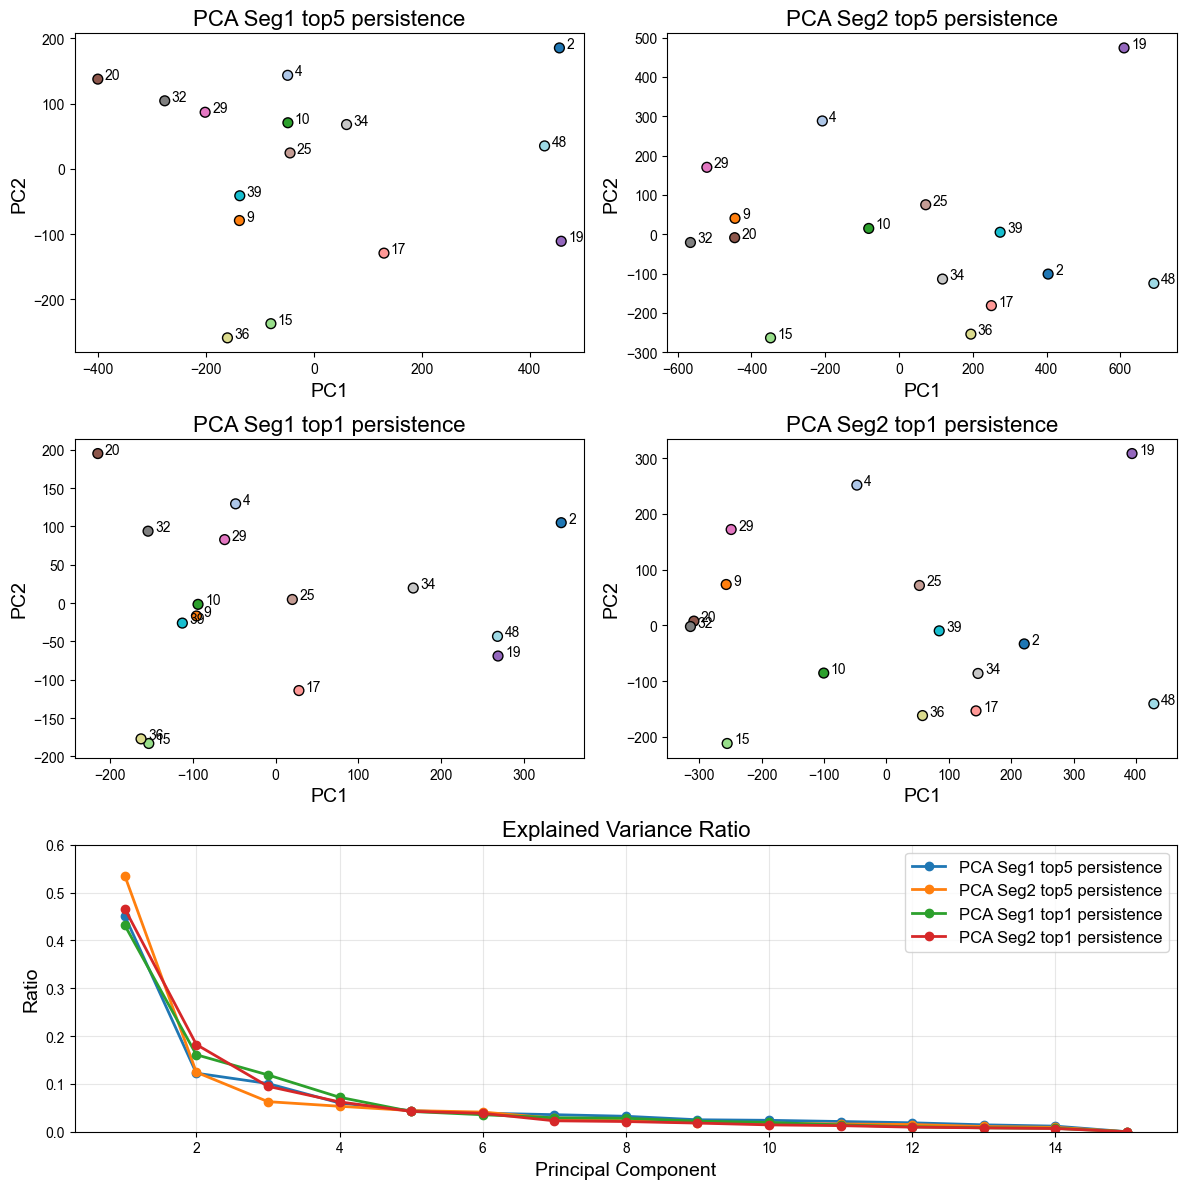

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

data_list = [project5longest_3dslicer, project5longest_medpseg, project5longest_3dslicer[:,::5], project5longest_medpseg[:,::5]]
titles = ["PCA Seg1 top5 persistence", "PCA Seg2 top5 persistence", "PCA Seg1 top1 persistence", "PCA Seg2 top1 persistence"]

id_to_num = {id_: i for i, id_ in enumerate(PatientID_list)}
num_labels = np.array([id_to_num[id_] for id_ in PatientID_list])

plt.rcParams["font.family"] = "Arial"

#---------------------------------------
# Figure layout
#---------------------------------------
fig = plt.figure(figsize=(12, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 0.9])

scatter_axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
]

ax_var = fig.add_subplot(gs[2, :])

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

#---------------------------------------
# PCA for each dataset
#---------------------------------------
for ax_scatter, Results_list, title, color in zip(
        scatter_axes, data_list, titles, colors):

    pca = PCA()
    feature = pca.fit_transform(Results_list)

    x = feature[:, 0]
    y = feature[:, 1]

    # Scatter plot
    ax_scatter.scatter(
        x,
        y,
        c=num_labels,
        cmap="tab20",
        s=50,
        edgecolors="k"
    )

    for j, txt in enumerate(PatientID_list):
        ax_scatter.annotate(
            txt,
            (x[j], y[j]),
            xytext=(5, 0),
            textcoords="offset points",
            fontsize=10
        )

    ax_scatter.set_title(title, fontsize=16)
    ax_scatter.set_xlabel("PC1", fontsize=14)
    ax_scatter.set_ylabel("PC2", fontsize=14)

    # Explained variance ratio
    var_ratio = pca.explained_variance_ratio_

    ax_var.plot(
        np.arange(1, len(var_ratio)+1),
        var_ratio,
        marker="o",
        linewidth=2,
        color=color,
        label=title
    )

#---------------------------------------
# Common EVR plot
#---------------------------------------
ax_var.set_title("Explained Variance Ratio", fontsize=16)
ax_var.set_xlabel("Principal Component", fontsize=14)
ax_var.set_ylabel("Ratio", fontsize=14)
ax_var.set_ylim(0, 0.6)
ax_var.legend(fontsize=12)
ax_var.grid(alpha=0.3)

plt.tight_layout()
plt.show()

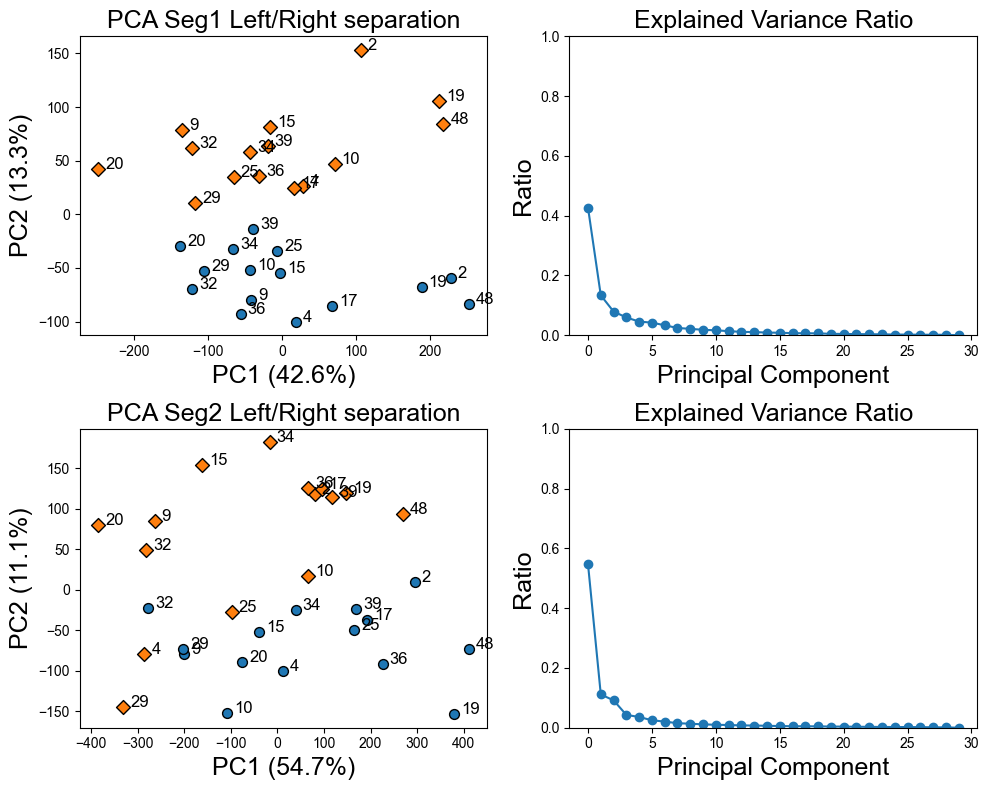

In [12]:
id_to_num = {id_: i for i, id_ in enumerate(PatientID_list)}
num_labels = np.array([id_to_num[id_] for id_ in PatientID_list])
plt.rcParams["font.family"] = "Arial"

data_list = [projectLR_3dslicer, projectLR_medpseg]
titles = ["PCA Seg1 Left/Right separation", "PCA Seg2 Left/Right separation"]

n = len(data_list)

fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))

for i, (Results_list, title) in enumerate(zip(data_list, titles)):
    ax_scatter = axes[i, 0]
    ax_var = axes[i, 1]

    pca = PCA()
    feature = pca.fit_transform(Results_list)

    x1, y1 = feature[0:15, 0], feature[0:15, 1]
    ax_scatter.scatter(x1, y1, s=50, edgecolors='k')

    for j, txt in enumerate(PatientID_list):
        ax_scatter.annotate(txt, (x1[j], y1[j]),
                            xytext=(5, 0),
                            textcoords='offset points',
                            fontsize=12)

    x2, y2 = feature[15:30, 0], feature[15:30, 1]
    ax_scatter.scatter(x2, y2, s=50, edgecolors='k', marker='D')

    for j, txt in enumerate(PatientID_list):
        ax_scatter.annotate(txt, (x2[j], y2[j]),
                            xytext=(5, 0),
                            textcoords='offset points',
                            fontsize=12)

    var_ratio = pca.explained_variance_ratio_

    ax_scatter.set_title(title, fontsize=18)
    ax_scatter.set_xlabel(f"PC1 ({var_ratio[0]*100:.1f}%)", fontsize=18)
    ax_scatter.set_ylabel(f"PC2 ({var_ratio[1]*100:.1f}%)", fontsize=18)

    ax_var.plot(var_ratio, marker='o')
    ax_var.set_title("Explained Variance Ratio", fontsize=18)
    ax_var.set_xlabel("Principal Component", fontsize=18)
    ax_var.set_ylabel("Ratio", fontsize=18)
    ax_var.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### RV coefficient calculation

In [13]:
### Definition of RV coefficient
def rv_coefficient(X, Y):
    X = X - X.mean(axis=0)### data centering
    Y = Y - Y.mean(axis=0)
    num = np.trace(X.T @ Y @ Y.T @ X)
    den = np.sqrt(np.trace(X.T @ X @ X.T @ X) * np.trace(Y.T @ Y @ Y.T @ Y))
    return num / den

In [14]:
### Cumulative explained variance ratio of the first 9 components for Projection PHT results
pca = PCA()
feature5_3dslicer = pca.fit_transform(project5longest_3dslicer)
print(np.sum(np.array(pca.explained_variance_ratio_[0:9])))
pca = PCA()
feature5_medpseg = pca.fit_transform(project5longest_medpseg)
print(np.sum(np.array(pca.explained_variance_ratio_[0:9])))
pca = PCA()
feature_3dslicer = pca.fit_transform(project5longest_3dslicer[:,::5])
print(np.sum(np.array(pca.explained_variance_ratio_[0:9])))
pca = PCA()
feature_medpseg = pca.fit_transform(project5longest_medpseg[:,::5])
print(np.sum(np.array(pca.explained_variance_ratio_[0:9])))

0.9100439289587874
0.9313054772694938
0.9407124526866185
0.9488098031262139


In [15]:
print("Projection PHT")
print("top5,2seg:",rv_coefficient(feature5_3dslicer[:,0:9],feature5_medpseg[:,0:9]))
print("top1,2seg:",rv_coefficient(feature_3dslicer[:,0:9],feature_medpseg[:,0:9]))
print("top5/1,Seg1:",rv_coefficient(feature5_3dslicer[:,0:9],feature_3dslicer[:,0:9]))
print("top5/1,Seg2:",rv_coefficient(feature5_medpseg[:,0:9],feature_medpseg[:,0:9]))

Projection PHT
top5,2seg: 0.7157059331468966
top1,2seg: 0.7277391267955576
top5/1,Seg1: 0.9292290980526118
top5/1,Seg2: 0.9558317156707092


### R/L classification with test data

In [19]:
### Class information for train dataset (half left. half right)
Class=np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])
len(Class),len(np.where(Class==0)[0])

(30, 15)

In [19]:
### Seg1 with Projection PHT
for regval in [0.1,0.5,1,3,5]:
    print("========")
    print("C=",regval)
    lr = LogisticRegression(C=regval,penalty='l2',random_state=0, solver='liblinear') 
    lr.fit(projectLR_3dslicer, Class)
    #print("coefficient = ", lr.coef_)
    #print("intercept = ", lr.intercept_)
    Y_pred = lr.predict(projectLR_3dslicer)
    print("train data classification")
    print(Y_pred)
    Y_pred = lr.predict(project_test_3dslicer)
    Y_proba=lr.predict_proba(project_test_3dslicer)
    print("test data result")
    print('prediction:',Y_pred)
    print('prediction probability:')
    print(Y_proba)

C= 0.1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1]
prediction probability:
[[9.99065704e-01 9.34295830e-04]
 [6.21255753e-01 3.78744247e-01]
 [9.99695115e-01 3.04884734e-04]
 [9.91155555e-01 8.84444537e-03]
 [2.44930784e-05 9.99975507e-01]
 [2.44538675e-01 7.55461325e-01]
 [7.95231531e-04 9.99204768e-01]
 [8.84036843e-05 9.99911596e-01]]
C= 0.5
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1]
prediction probability:
[[9.99784537e-01 2.15463385e-04]
 [6.07343811e-01 3.92656189e-01]
 [9.99946744e-01 5.32559614e-05]
 [9.96628824e-01 3.37117603e-03]
 [3.22162731e-06 9.99996778e-01]
 [1.92410693e-01 8.07589307e-01]
 [1.88423159e-04 9.99811577e-01]
 [1.45734728e-05 9.99985427e-01]]
C= 1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1

In [20]:
### Seg2 with Projection PHT
for regval in [0.1,0.5,1,3,5]:
    print("========")
    print("C=",regval)
    lr = LogisticRegression(C=regval,penalty='l2',random_state=0, solver='liblinear') 
    lr.fit(projectLR_medpseg, Class)
    #print("coefficient = ", lr.coef_)
    #print("intercept = ", lr.intercept_)
    Y_pred = lr.predict(projectLR_medpseg)
    print("train data classification")
    print(Y_pred)
    Y_pred = lr.predict(project_test_medpseg)
    Y_proba=lr.predict_proba(project_test_medpseg)
    print("test data result")
    print('prediction:',Y_pred)
    print('prediction probability:')
    print(Y_proba)

C= 0.1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1]
prediction probability:
[[9.97376086e-01 2.62391442e-03]
 [9.98457196e-01 1.54280393e-03]
 [9.99846443e-01 1.53556623e-04]
 [9.95237703e-01 4.76229684e-03]
 [2.03141452e-04 9.99796859e-01]
 [6.32293350e-05 9.99936771e-01]
 [1.10711859e-04 9.99889288e-01]
 [8.75807851e-04 9.99124192e-01]]
C= 0.5
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1]
prediction probability:
[[9.99269136e-01 7.30864259e-04]
 [9.99570051e-01 4.29948585e-04]
 [9.99976273e-01 2.37265617e-05]
 [9.98348011e-01 1.65198928e-03]
 [3.34354990e-05 9.99966565e-01]
 [7.32483068e-06 9.99992675e-01]
 [1.67943340e-05 9.99983206e-01]
 [1.94592200e-04 9.99805408e-01]]
C= 1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1

In [21]:
### generalize across different segmentation methods
print("Projection PHT Seg1 > Seg2")
lr = LogisticRegression(C=1,penalty='l2',random_state=0, solver='liblinear') 
lr.fit(projectLR_3dslicer, Class)
Y_pred = lr.predict(project_test_medpseg)
print("test data result")
print('prediction:',Y_pred)

print("Projection PHT Seg2 > Seg1")
lr = LogisticRegression(C=1,penalty='l2',random_state=0, solver='liblinear') 
lr.fit(projectLR_medpseg, Class)
Y_pred = lr.predict(project_test_3dslicer)
print("test data result")
print('prediction:',Y_pred)


Projection PHT Seg1 > Seg2
test data result
prediction: [0 0 0 0 1 1 1 1]
Projection PHT Seg2 > Seg1
test data result
prediction: [0 1 0 0 1 1 1 1]


### Contribution analysis

In [6]:
### PC2 for Projection PHT with Seg1 separated L/R clearly.
pca = PCA()
feature = pca.fit_transform(projectLR_3dslicer)

In [7]:
### PC1 values are R negative, L positive
feature[:,1]

array([ -59.14880001, -100.03007867,  -79.40776231,  -51.45177473,
        -54.73381952,  -85.68294558,  -67.80106072,  -29.9523838 ,
        -34.16072808,  -52.54060655,  -69.49520437,  -32.31048704,
        -93.1515956 ,  -13.30052119,  -83.85138237,  153.32731095,
         26.17939069,   78.31419976,   46.94005307,   81.28117804,
         24.46925521,  105.91663165,   42.23117193,   34.6712663 ,
         10.99133334,   61.9196071 ,   57.84599586,   35.59122535,
         63.3834225 ,   83.95710881])

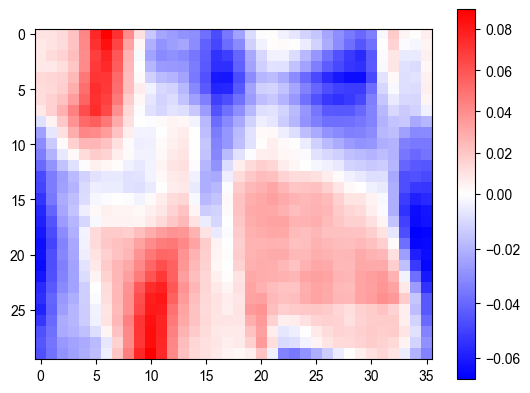

In [13]:
### Positive values contribute to left-likeness, negative values contribute to right-likeness
from matplotlib.colors import TwoSlopeNorm
grid1 = pca.components_[1].reshape((30, 36)) 
vmin = np.min(grid1)
vmax = np.max(grid1)
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

plt.imshow(grid1, cmap='bwr', norm=norm)
plt.colorbar()
plt.show()

In [17]:
### Although it is difficult to interpret everything, we can see, for example, that the very red parts in the left hand side corresponds to the longer main branch of left airways seen from front and back.

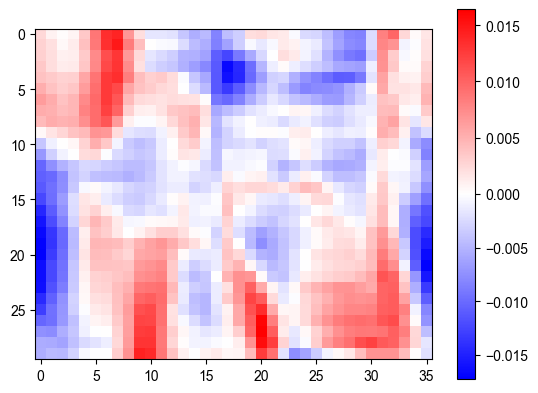

In [20]:
lr = LogisticRegression(C=1,penalty='l2',random_state=0, solver='liblinear') 
lr.fit(projectLR_3dslicer, Class)
from matplotlib.colors import TwoSlopeNorm
plt.rcParams["font.family"] = "Arial"
grid2 = lr.coef_.reshape((30, 36)) 
# 値の範囲
vmin = np.min(grid2)
vmax = np.max(grid2)

# 0を中央（白）に固定
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

plt.imshow(grid2, cmap='bwr', norm=norm)
plt.colorbar()
plt.show()

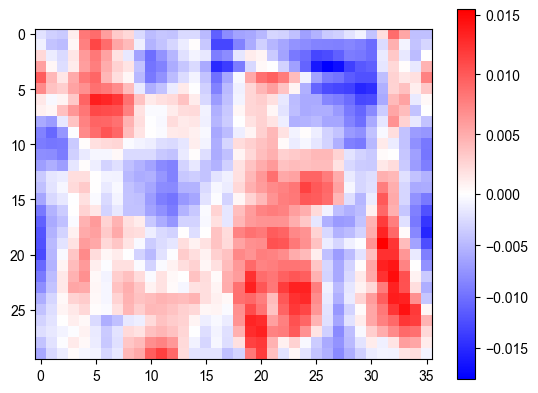

In [21]:
lr = LogisticRegression(C=1,penalty='l2',random_state=0, solver='liblinear') 
lr.fit(projectLR_medpseg, Class)
from matplotlib.colors import TwoSlopeNorm
plt.rcParams["font.family"] = "Arial"
grid3 = lr.coef_.reshape((30, 36)) 
# 値の範囲
vmin = np.min(grid3)
vmax = np.max(grid3)

# 0を中央（白）に固定
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

plt.imshow(grid3, cmap='bwr', norm=norm)
plt.colorbar()
plt.show()

### Subset model

In [22]:
## upward
### Seg1
col_idx = np.arange(projectLR_3dslicer.shape[1])
mask = np.isin(col_idx % 36, [7, 8, 9])
projectLR_3dslicer_upward=projectLR_3dslicer[:,mask]
print(projectLR_3dslicer_upward.shape)
col_idx = np.arange(project_test_3dslicer.shape[1])
mask = np.isin(col_idx % 36, [7, 8, 9])
project_test_3dslicer_upward=project_test_3dslicer[:,mask]
print(project_test_3dslicer_upward.shape)
### Seg2
col_idx = np.arange(projectLR_medpseg.shape[1])
mask = np.isin(col_idx % 36, [7, 8, 9])
projectLR_medpseg_upward=projectLR_medpseg[:,mask]
print(projectLR_medpseg_upward.shape)
col_idx = np.arange(project_test_medpseg.shape[1])
mask = np.isin(col_idx % 36, [7, 8, 9])
project_test_medpseg_upward=project_test_medpseg[:,mask]
print(project_test_medpseg_upward.shape)

(30, 90)
(8, 90)
(30, 90)
(8, 90)


In [23]:
for regval in [0.1,0.5,1,3,5]:
    print("========")
    print("C=",regval)
    lr = LogisticRegression(C=regval,penalty='l2',random_state=0, solver='liblinear') 
    lr.fit(projectLR_3dslicer_upward, Class)
    #print("coefficient = ", lr.coef_)
    #print("intercept = ", lr.intercept_)
    Y_pred = lr.predict(projectLR_3dslicer_upward)
    print("train data classification")
    print(Y_pred)
    Y_pred = lr.predict(project_test_3dslicer_upward)
    Y_proba=lr.predict_proba(project_test_3dslicer_upward)
    print("test data result")
    print('prediction:',Y_pred)
    print('prediction probability:')
    print(Y_proba)

C= 0.1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 1 0 0 1 1 1 1]
prediction probability:
[[9.97375613e-01 2.62438703e-03]
 [3.81058642e-02 9.61894136e-01]
 [7.40274317e-01 2.59725683e-01]
 [9.89654212e-01 1.03457883e-02]
 [5.41893437e-05 9.99945811e-01]
 [5.11569449e-02 9.48843055e-01]
 [1.41890190e-03 9.98581098e-01]
 [5.34062719e-04 9.99465937e-01]]
C= 0.5
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 1 0 0 1 1 1 1]
prediction probability:
[[9.99696300e-01 3.03699756e-04]
 [8.19208883e-03 9.91807911e-01]
 [9.32182457e-01 6.78175433e-02]
 [9.99291236e-01 7.08763927e-04]
 [1.32174765e-06 9.99998678e-01]
 [1.45347207e-02 9.85465279e-01]
 [1.69036800e-04 9.99830963e-01]
 [1.75405954e-05 9.99982459e-01]]
C= 1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 1 0 0 1 1 1 1

In [24]:
for regval in [0.1,0.5,1,3,5]:
    print("========")
    print("C=",regval)
    lr = LogisticRegression(C=regval,penalty='l2',random_state=0, solver='liblinear') 
    lr.fit(projectLR_medpseg_upward, Class)
    #print("coefficient = ", lr.coef_)
    #print("intercept = ", lr.intercept_)
    Y_pred = lr.predict(projectLR_medpseg_upward)
    print("train data classification")
    print(Y_pred)
    Y_pred = lr.predict(project_test_medpseg_upward)
    Y_proba=lr.predict_proba(project_test_medpseg_upward)
    print("test data result")
    print('prediction:',Y_pred)
    print('prediction probability:')
    print(Y_proba)

C= 0.1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 1 0 0 1 1 1 1]
prediction probability:
[[6.40209106e-01 3.59790894e-01]
 [2.11696123e-01 7.88303877e-01]
 [6.38411135e-01 3.61588865e-01]
 [7.12154979e-01 2.87845021e-01]
 [7.15600756e-04 9.99284399e-01]
 [4.41170395e-04 9.99558830e-01]
 [3.67342289e-01 6.32657711e-01]
 [9.06549428e-03 9.90934506e-01]]
C= 0.5
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 1 0 0 1 1 1 1]
prediction probability:
[[5.80658052e-01 4.19341948e-01]
 [1.36161477e-01 8.63838523e-01]
 [7.26057737e-01 2.73942263e-01]
 [7.39208099e-01 2.60791901e-01]
 [4.93700699e-05 9.99950630e-01]
 [2.41844176e-05 9.99975816e-01]
 [3.20838891e-01 6.79161109e-01]
 [9.83248338e-04 9.99016752e-01]]
C= 1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 1 0 0 1 1 1 1

In [25]:
## downward
### Seg1
col_idx = np.arange(projectLR_3dslicer.shape[1])
mask = np.isin(col_idx % 36, [25, 26, 27])
projectLR_3dslicer_downward=projectLR_3dslicer[:,mask]
print(projectLR_3dslicer_downward.shape)
col_idx = np.arange(project_test_3dslicer.shape[1])
mask = np.isin(col_idx % 36, [25, 26, 27])
project_test_3dslicer_downward=project_test_3dslicer[:,mask]
print(project_test_3dslicer_downward.shape)
### Seg2
col_idx = np.arange(projectLR_medpseg.shape[1])
mask = np.isin(col_idx % 36, [25, 26, 27])
projectLR_medpseg_downward=projectLR_medpseg[:,mask]
print(projectLR_medpseg_downward.shape)
col_idx = np.arange(project_test_medpseg.shape[1])
mask = np.isin(col_idx % 36, [25, 26, 27])
project_test_medpseg_downward=project_test_medpseg[:,mask]
print(project_test_medpseg_downward.shape)

(30, 90)
(8, 90)
(30, 90)
(8, 90)


In [26]:
for regval in [0.1,0.5,1,3,5]:
    print("========")
    print("C=",regval)
    lr = LogisticRegression(C=regval,penalty='l2',random_state=0, solver='liblinear') 
    lr.fit(projectLR_3dslicer_downward, Class)
    #print("coefficient = ", lr.coef_)
    #print("intercept = ", lr.intercept_)
    Y_pred = lr.predict(projectLR_3dslicer_downward)
    print("train data classification")
    print(Y_pred)
    Y_pred = lr.predict(project_test_3dslicer_downward)
    Y_proba=lr.predict_proba(project_test_3dslicer_downward)
    print("test data result")
    print('prediction:',Y_pred)
    print('prediction probability:')
    print(Y_proba)

C= 0.1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [1 0 1 1 1 0 1 0]
prediction probability:
[[1.35699715e-01 8.64300285e-01]
 [9.37616835e-01 6.23831649e-02]
 [1.44245518e-01 8.55754482e-01]
 [1.54401113e-01 8.45598887e-01]
 [6.36773065e-04 9.99363227e-01]
 [8.46004798e-01 1.53995202e-01]
 [7.28712318e-02 9.27128768e-01]
 [8.39870735e-01 1.60129265e-01]]
C= 0.5
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [1 0 1 1 1 0 1 0]
prediction probability:
[[1.08853817e-01 8.91146183e-01]
 [9.87545821e-01 1.24541795e-02]
 [7.91657808e-02 9.20834219e-01]
 [6.38944364e-02 9.36105564e-01]
 [6.26236997e-06 9.99993738e-01]
 [9.45924669e-01 5.40753312e-02]
 [1.16456060e-02 9.88354394e-01]
 [9.51277661e-01 4.87223395e-02]]
C= 1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [1 0 1 1 1 0 1 0

In [27]:
for regval in [0.1,0.5,1,3,5]:
    print("========")
    print("C=",regval)
    lr = LogisticRegression(C=regval,penalty='l2',random_state=0, solver='liblinear') 
    lr.fit(projectLR_medpseg_downward, Class)
    #print("coefficient = ", lr.coef_)
    #print("intercept = ", lr.intercept_)
    Y_pred = lr.predict(projectLR_medpseg_downward)
    print("train data classification")
    print(Y_pred)
    Y_pred = lr.predict(project_test_medpseg_downward)
    Y_proba=lr.predict_proba(project_test_medpseg_downward)
    print("test data result")
    print('prediction:',Y_pred)
    print('prediction probability:')
    print(Y_proba)

C= 0.1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [1 0 1 1 1 1 1 1]
prediction probability:
[[4.62328174e-01 5.37671826e-01]
 [9.54919748e-01 4.50802516e-02]
 [5.00824671e-03 9.94991753e-01]
 [3.45832424e-01 6.54167576e-01]
 [2.32426539e-03 9.97675735e-01]
 [2.18168520e-04 9.99781831e-01]
 [2.69650849e-04 9.99730349e-01]
 [1.71851228e-03 9.98281488e-01]]
C= 0.5
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [1 0 1 1 1 1 1 1]
prediction probability:
[[4.95753200e-01 5.04246800e-01]
 [9.72249577e-01 2.77504234e-02]
 [4.51572160e-04 9.99548428e-01]
 [3.26518587e-01 6.73481413e-01]
 [2.30481779e-04 9.99769518e-01]
 [8.19011879e-06 9.99991810e-01]
 [1.89476797e-05 9.99981052e-01]
 [2.17097447e-04 9.99782903e-01]]
C= 1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 1 1 1 1 1 1